# Experiment NLP — Praktik Python untuk Sains Data [Pekan 9]

**Pertemuan 9 · CSI3F3 Prinsip Sains Data · Program Magister Informatika**  
**Pengampu:** Dr. Warih Maharani

---

Notebook ini melengkapi *Slide 9 NLP* dengan implementasi dalam Python.
Tiap tahap berkorespondensi dengan blok materi pada slide:

| # | Tahapan | Materi slide |
|---|----------|--------------|
| 0 | Setup & dataset | – |
| 1 | Text Preprocessing | Slide 10–12 |
| 2 | Feature Extraction (BoW & TF–IDF) | Slide 13 |
| 3 | Word Embeddings (Word2Vec) | Slide 15–16 |
| 4 | N-gram Language Model & Perplexity | Slide 14 |
| 5 | Text Classification (Naive Bayes & LR) | Slide 17 |
| 6 | Sequence Labeling (POS & NER) | Slide 18 |
| 7 | Neural NLP — LSTM dengan PyTorch | Slide 19–20 |
| 8 | Transformer & BERT (Hugging Face) | Slide 21–22 |
| 9 | Era LLM — Embedding & Mini-RAG | Slide 23 |

**Cara menjalankan:** notebook didesain agar *self-contained* — tiap workshop bisa dijalankan independen.
Disarankan menggunakan Google Colab (GPU runtime untuk Workshop 7–9).

**Catatan:** kode ini dirancang untuk memahami *konsep*.
Untuk develop sistem, pertimbangkan optimasi (vectorisasi numpy, batching, mixed precision).

## Tahap 0 — Setup

Install libraries.

In [1]:
# !pip install -q nltk spacy scikit-learn gensim sastrawi
# !pip install -q torch transformers datasets evaluate
# !pip install -q sentence-transformers seqeval
# !python -m spacy download en_core_web_sm -q

import warnings; warnings.filterwarnings('ignore')
import numpy as np, pandas as pd, random, math
import matplotlib.pyplot as plt

RNG = 42; np.random.seed(RNG); random.seed(RNG)
print('Setup OK. Numpy', np.__version__, '| Pandas', pd.__version__)

Setup OK. Numpy 1.26.4 | Pandas 2.2.3


### Sample dataset

Kita gunakan dua small dataset agar experiment dapat dijalankan dengan efektif dan efisien:
1. **`reviews_id`** — review produk berbahasa Indonesia (positif / negatif).
2. **`news_corpus`** — kumpulan kalimat berita untuk eksperimen embedding & language model.

Untuk eksperimen lebih besar, gunakan dataset publik seperti: `IndoNLU SmSA`, `Liputan6`, `IndoSum`.

In [2]:
reviews_id = pd.DataFrame({
    'text': [
        'Produknya bagus banget, pengiriman cepat dan packing rapi.',
        'Kualitas mengecewakan, barang rusak sebelum sempat dipakai.',
        'Harga terjangkau dan rasa enak, akan beli lagi besok.',
        'Pelayanan kurang ramah, antrian panjang, sangat lambat.',
        'Sangat puas dengan baterai laptop ini, awet seharian penuh.',
        'Buruk sekali, software sering crash dan dukungan tidak responsif.',
        'Pengalaman menginap menyenangkan, kamar bersih dan staf membantu.',
        'Hotel kotor, AC mati, tidak akan kembali lagi.',
        'Kopi nya enak, suasana cafe nyaman untuk kerja.',
        'Pesanan saya salah dan kurir tidak bertanggung jawab.',
        'Pelayanan ramah dan profesional, terima kasih banyak!',
        'Aplikasinya berat dan banyak iklan, tidak nyaman dipakai.',
    ],
    'label': ['pos','neg','pos','neg','pos','neg','pos','neg','pos','neg','pos','neg']
})
reviews_id

,text,label
0,"Produknya bagus banget, pengiriman cepat dan p...",pos
1,"Kualitas mengecewakan, barang rusak sebelum se...",neg
2,"Harga terjangkau dan rasa enak, akan beli lagi...",pos
3,"Pelayanan kurang ramah, antrian panjang, sanga...",neg
4,"Sangat puas dengan baterai laptop ini, awet se...",pos
5,"Buruk sekali, software sering crash dan dukung...",neg
6,"Pengalaman menginap menyenangkan, kamar bersih...",pos
7,"Hotel kotor, AC mati, tidak akan kembali lagi.",neg
8,"Kopi nya enak, suasana cafe nyaman untuk kerja.",pos
9,Pesanan saya salah dan kurir tidak bertanggung...,neg


In [3]:
news_corpus = [
    'Bank Indonesia menaikkan suku bunga acuan menjadi 5,75 persen pada Januari.',
    'Pemerintah merilis paket stimulus untuk usaha kecil dan menengah.',
    'Inflasi inti turun menjadi 2,4 persen seiring stabilnya harga pangan.',
    'Kementerian Keuangan menetapkan target pertumbuhan ekonomi sebesar 5,2 persen.',
    'Bursa saham Indonesia menguat ditopang aksi beli investor asing.',
    'OJK memperketat aturan pinjaman online untuk melindungi konsumen.',
    'Rupiah menguat tipis terhadap dolar Amerika di pasar spot.',
    'Cadangan devisa Indonesia naik menjadi 144 miliar dolar pada Februari.',
    'Telkom meluncurkan layanan AI agentic untuk pelaku UMKM Indonesia.',
    'Universitas Telkom membuka program magister informatika berbasis AI.',
]
len(news_corpus), news_corpus[0]

(10,
 'Bank Indonesia menaikkan suku bunga acuan menjadi 5,75 persen pada Januari.')

---
## Tahap 1 — Text Preprocessing

**Tujuan:** mengubah teks mentah menjadi token yang siap diolah model.

Pipeline: **cleaning → tokenization → normalization → stopword removal → stemming/lemmatization**.

Catatan: untuk model kontekstual (BERT/LLM), beberapa langkah tidak diperlukan, gunakan tokenizer bawaan model.

### 1.1 Cleaning dengan regex

In [4]:
import re

raw = 'Halo!! Cek <b>promo</b> di https://example.com 😊  Hub. 0812-3456-7890 atau email a@b.id'

def clean_text(t: str) -> str:
    t = re.sub(r'<[^>]+>', ' ', t)              # HTML tag
    t = re.sub(r'http\S+|www\.\S+', ' <URL> ', t)  # URL
    t = re.sub(r'[\w\.-]+@[\w\.-]+', ' <EMAIL> ', t) # email
    t = re.sub(r'\b\d{2,4}-?\d{3,4}-?\d{3,4}\b', ' <PHONE> ', t)  # nomor telepon
    t = re.sub(r'[^\w\s<>.,!?]', ' ', t)       # buang emoji & simbol aneh
    t = re.sub(r'\s+', ' ', t).strip()          # whitespace
    return t.lower()

print(clean_text(raw))

halo!! cek promo di <url> hub. <phone> atau email <email>


### 1.2 Tokenization

Tokenization memecah teks menjadi unit (kata atau subword). Bandingkan beberapa pendekatan:

In [5]:
import nltk
for pkg in ['punkt', 'punkt_tab', 'averaged_perceptron_tagger', 'stopwords']:
    try: nltk.data.find(pkg);
    except LookupError: nltk.download(pkg, quiet=True)

from nltk.tokenize import word_tokenize, sent_tokenize
txt = 'Bank Indonesia menaikkan suku bunga. Investor merespons positif.'
print('Sentences :', sent_tokenize(txt))
print('Words     :', word_tokenize(txt))

Sentences : ['Bank Indonesia menaikkan suku bunga.', 'Investor merespons positif.']
Words     : ['Bank', 'Indonesia', 'menaikkan', 'suku', 'bunga', '.', 'Investor', 'merespons', 'positif', '.']


In [6]:
# spaCy — tokenizer + linguistic features
import spacy
try:
    nlp_en = spacy.load('en_core_web_sm')
except OSError:
    from spacy.cli import download; download('en_core_web_sm'); nlp_en = spacy.load('en_core_web_sm')

doc = nlp_en('NLP is fascinating, especially Transformer architectures!')
for tok in doc:
    print(f'{tok.text:<14} lemma={tok.lemma_:<12} pos={tok.pos_:<6} stop={tok.is_stop}')

NLP            lemma=NLP          pos=PROPN  stop=False
is             lemma=be           pos=AUX    stop=True
fascinating    lemma=fascinating  pos=ADJ    stop=False
,              lemma=,            pos=PUNCT  stop=False
especially     lemma=especially   pos=ADV    stop=False
Transformer    lemma=Transformer  pos=PROPN  stop=False
architectures  lemma=architecture pos=NOUN   stop=False
!              lemma=!            pos=PUNCT  stop=False


### 1.3 Subword tokenization — Byte-Pair Encoding (BPE)

BPE menggabungkan pasangan karakter paling sering. Implementasi di bawah menjelaskan algoritmanya.

In [7]:
from collections import Counter, defaultdict

def get_stats(vocab):
    pairs = defaultdict(int)
    for word, freq in vocab.items():
        symbols = word.split()
        for i in range(len(symbols)-1):
            pairs[(symbols[i], symbols[i+1])] += freq
    return pairs

def merge_vocab(pair, v_in):
    v_out = {}
    bigram = ' '.join(pair)
    replacement = ''.join(pair)
    for word in v_in:
        w = word.replace(bigram, replacement)
        v_out[w] = v_in[word]
    return v_out

# vocab awal — karakter dipisah spasi, diakhiri </w>
raw_words = ['low']*5 + ['lower']*2 + ['newest']*6 + ['widest']*3
vocab = Counter(' '.join(list(w) + ['</w>']) for w in raw_words)
vocab = dict(vocab)

for it in range(8):
    pairs = get_stats(vocab)
    if not pairs: break
    best = max(pairs, key=pairs.get)
    vocab = merge_vocab(best, vocab)
    print(f'Iter {it+1}: merge {best} -> {"".join(best)}')

print('\nVocab final:', vocab)

Iter 1: merge ('e', 's') -> es
Iter 2: merge ('es', 't') -> est
Iter 3: merge ('est', '</w>') -> est</w>
Iter 4: merge ('l', 'o') -> lo
Iter 5: merge ('lo', 'w') -> low
Iter 6: merge ('n', 'e') -> ne
Iter 7: merge ('ne', 'w') -> new
Iter 8: merge ('new', 'est</w>') -> newest</w>

Vocab final: {'low </w>': 5, 'low e r </w>': 2, 'newest</w>': 6, 'w i d est</w>': 3}


### 1.4 Stopword removal & stemming/lemmatization

**English** menggunakan NLTK + spaCy, **Indonesia** menggunakan Sastrawi.

In [8]:
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
ps = PorterStemmer()

tokens = ['running','runner','ran','easily','better','studies','studying']
print('Porter stem :', [ps.stem(t) for t in tokens])
print('spaCy lemma :', [tok.lemma_ for tok in nlp_en(' '.join(tokens))])

Porter stem : ['run', 'runner', 'ran', 'easili', 'better', 'studi', 'studi']
spaCy lemma : ['run', 'runner', 'run', 'easily', 'well', 'study', 'study']


In [9]:
import sys
if 'Sastrawi' not in sys.modules:
    !pip install sastrawi

# Bahasa Indonesia: Sastrawi
try:
    from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
    from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory
except ImportError:
    print('!pip install sastrawi  -- jalankan baris ini lalu re-run')
    raise

stemmer = StemmerFactory().create_stemmer()
sw_remover = StopWordRemoverFactory().create_stop_word_remover()

kalimat = 'Pemerintah sedang mempersiapkan kebijakan baru untuk meningkatkan ekonomi nasional.'
no_sw = sw_remover.remove(kalimat)
stemmed = stemmer.stem(no_sw)
print('Asli   :', kalimat)
print('No SW  :', no_sw)
print('Stem   :', stemmed)

Defaulting to user installation because normal site-packages is not writeable

[notice] A new release of pip is available: 25.0.1 -> 26.1
[notice] To update, run: python3 -m pip install --upgrade pip
Asli   : Pemerintah sedang mempersiapkan kebijakan baru untuk meningkatkan ekonomi nasional.
No SW  : Pemerintah sedang mempersiapkan kebijakan baru meningkatkan ekonomi nasional.
Stem   : perintah sedang siap bijak baru tingkat ekonomi nasional


### 1.5 Pipeline (English + Indonesia)

In [10]:
def preprocess_en(text: str):
    text = clean_text(text)
    doc = nlp_en(text)
    return [tok.lemma_ for tok in doc if tok.is_alpha and not tok.is_stop]

def preprocess_id(text: str):
    text = clean_text(text)
    text = sw_remover.remove(text)
    text = stemmer.stem(text)
    return [t for t in text.split() if len(t) > 1]

print('EN :', preprocess_en('The quick brown fox is running over the lazy dogs!'))
print('ID :', preprocess_id(reviews_id['text'].iloc[0]))

EN : ['quick', 'brown', 'fox', 'run', 'lazy', 'dog']
ID : ['produk', 'bagus', 'banget', 'kirim', 'cepat', 'packing', 'rapi']


---
## Tahap 2 — Feature Extraction: BoW & TF–IDF

**Tujuan:** mengubah teks menjadi vektor numerik. Kita bandingkan implementasi manual
dengan library `scikit-learn`.

Recall formula:
$$ \text{tfidf}(t,d,D) = \text{tf}(t,d) \cdot \log\frac{N}{|\{d \in D : t \in d\}|} $$

### 2.1 BoW manual

In [11]:
docs = [preprocess_id(t) for t in reviews_id['text']]
vocab = sorted({w for d in docs for w in d})
w2i = {w:i for i,w in enumerate(vocab)}

def bow_vector(doc, w2i):
    v = np.zeros(len(w2i), dtype=int)
    for w in doc:
        if w in w2i: v[w2i[w]] += 1
    return v

X_bow = np.vstack([bow_vector(d, w2i) for d in docs])
print('Shape BoW:', X_bow.shape, '| vocab size:', len(vocab))
pd.DataFrame(X_bow[:4], columns=vocab).iloc[:, :12]

Shape BoW: (12, 71) | vocab size: 71


,ac,akan,alam,antri,aplikasi,awet,bagus,banget,bantu,banyak,barang,baterai
0,0,0,0,0,0,0,1,1,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,1,0
2,0,0,0,0,0,0,0,0,0,0,0,0
3,0,0,0,1,0,0,0,0,0,0,0,0


### 2.2 TF–IDF manual

In [12]:
N = len(docs)
df = (X_bow > 0).sum(axis=0)            # document frequency
idf = np.log(N / df)                     # idf
tf  = X_bow / np.maximum(X_bow.sum(axis=1, keepdims=True), 1)  # tf normalisasi
tfidf_manual = tf * idf

print('IDF kata pertama:', dict(zip(vocab[:6], np.round(idf[:6], 3))))
print('Top kata di doc-0:')
top_idx = tfidf_manual[0].argsort()[::-1][:5]
for i in top_idx:
    print(f'  {vocab[i]:<14}  tfidf={tfidf_manual[0][i]:.3f}')

IDF kata pertama: {'ac': 2.485, 'akan': 2.485, 'alam': 2.485, 'antri': 2.485, 'aplikasi': 2.485, 'awet': 2.485}
Top kata di doc-0:
  packing         tfidf=0.355
  cepat           tfidf=0.355
  produk          tfidf=0.355
  banget          tfidf=0.355
  bagus           tfidf=0.355


### 2.3 TF–IDF dengan scikit-learn

In [13]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfv = TfidfVectorizer(
    preprocessor=lambda t: t.lower(),
    tokenizer=str.split,
    ngram_range=(1, 2),         # unigram + bigram
    min_df=1, sublinear_tf=True
)
joined = [' '.join(d) for d in docs]
X = tfv.fit_transform(joined)
print('Shape TF-IDF:', X.shape)
print('Sample fitur (n-gram):', list(tfv.vocabulary_.keys())[:15])

Shape TF-IDF: (12, 137)
Sample fitur (n-gram): ['produk', 'bagus', 'banget', 'kirim', 'cepat', 'packing', 'rapi', 'produk bagus', 'bagus banget', 'banget kirim', 'kirim cepat', 'cepat packing', 'packing rapi', 'kualitas', 'kecewa']


---
## Tahap 3 — Word Embeddings dengan Word2Vec

**Tujuan:** mempelajari representasi distributional. Kita melatih Word2Vec (small)
pada korpus berita, lalu mengukur kemiripan kata dan analogi.

*Catatan:* untuk hasil yang lebih optimal butuh korpus yang lebih besar.

In [14]:
!pip install gensim
from gensim.models import Word2Vec

tokenized = [preprocess_id(s) for s in news_corpus]
tokenized = [t for t in tokenized if t]

w2v = Word2Vec(sentences=tokenized,
               vector_size=50, window=4,
               min_count=1, sg=1,                # 1=skip-gram, 0=CBOW
               negative=5, epochs=200, seed=RNG)

print('Vocab size:', len(w2v.wv.key_to_index))
print('Vector "bunga" (5 dim awal):', w2v.wv['bunga'][:5])
print('Most similar to "bunga":', w2v.wv.most_similar('bunga', topn=5))

Defaulting to user installation because normal site-packages is not writeable
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 97.1 MB/s eta 0:00:00ta 0:00:01

[notice] A new release of pip is available: 25.0.1 -> 26.1
[notice] To update, run: python3 -m pip install --upgrade pip
Vocab size: 70
Vector "bunga" (5 dim awal): [ 0.01631024 -0.01933177 -0.02202277  0.0138192   0.06087263]
Most similar to "bunga": [('indonesia', 0.9539139270782471), ('persen', 0.9377553462982178), ('naik', 0.9350163340568542), ('jadi', 0.9287477731704712), ('kuat', 0.9269987344741821)]


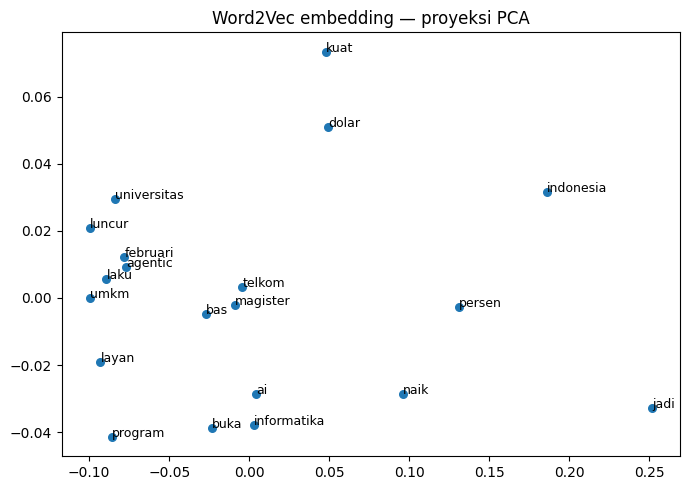

In [15]:
# Visualisasi 2D dengan PCA
from sklearn.decomposition import PCA

kata = list(w2v.wv.key_to_index)[:20]
vecs = np.array([w2v.wv[w] for w in kata])
p = PCA(n_components=2).fit_transform(vecs)

plt.figure(figsize=(7,5))
plt.scatter(p[:,0], p[:,1], s=30)
for i, w in enumerate(kata):
    plt.annotate(w, (p[i,0], p[i,1]), fontsize=9)
plt.title('Word2Vec embedding — proyeksi PCA')
plt.tight_layout(); plt.show()

---
## Tahap 4 — N-gram Language Model & Perplexity

**Tujuan:** membangun bigram language model dari nol, mengaplikasikan Laplace smoothing,
menghitung **perplexity**, dan menggenerasi teks dari distribusi.

Recall:
$$P(w_t \mid w_{t-1}) = \frac{\text{count}(w_{t-1}, w_t) + 1}{\text{count}(w_{t-1}) + |V|}$$
$$\text{PP}(W) = \exp\!\left(-\frac{1}{T}\sum_t \log P(w_t \mid w_{t-1})\right)$$

In [16]:
from collections import Counter, defaultdict

def make_bigram_lm(corpus_tokens):
    unigram = Counter(); bigram = Counter()
    for sent in corpus_tokens:
        sent = ['<s>'] + sent + ['</s>']
        unigram.update(sent)
        bigram.update(zip(sent[:-1], sent[1:]))
    V = len(unigram)
    def prob(w_prev, w):
        return (bigram[(w_prev, w)] + 1) / (unigram[w_prev] + V)
    return prob, unigram, bigram, V

tokenized = [preprocess_id(s) for s in news_corpus]
prob, unig, big, V = make_bigram_lm(tokenized)
print('|V|=', V, '| P(naik | bunga) =', round(prob('bunga','naik'), 4))

|V|= 72 | P(naik | bunga) = 0.0137


In [17]:
def perplexity(prob, sent_tokens):
    sent = ['<s>'] + sent_tokens + ['</s>']
    log_prob = 0.0
    for i in range(1, len(sent)):
        log_prob += math.log(prob(sent[i-1], sent[i]))
    return math.exp(-log_prob / (len(sent) - 1))

test = preprocess_id('Bank menaikkan suku bunga acuan')
print('Test tokens:', test)
print('Perplexity :', round(perplexity(prob, test), 2))

Test tokens: ['bank', 'naik', 'suku', 'bunga', 'acu']
Perplexity : 46.99


In [18]:
def sample_next(prev):
    cands = [w for (a, w) in big if a == prev]
    if not cands: return '</s>'
    weights = np.array([prob(prev, w) for w in cands])
    weights /= weights.sum()
    return np.random.choice(cands, p=weights)

np.random.seed(7)
out = ['<s>']
while out[-1] != '</s>' and len(out) < 15:
    out.append(sample_next(out[-1]))
print('Generated:', ' '.join(out))

Generated: <s> bank indonesia kuat tipis dolar februari </s>


---
## Tahap 5 — Text Classification

**Tujuan:** membandingkan **Multinomial Naive Bayes** (generative) dan
**Logistic Regression** (discriminative) untuk klasifikasi sentimen.

Recall Naive Bayes:
$$\hat y = \arg\max_y \log P(y) + \sum_{w \in d} \text{count}(w, d) \cdot \log P(w \mid y)$$

In [19]:
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score

X_text = reviews_id['text'].tolist()
y = reviews_id['label'].tolist()

pipes = {
    'NB'  : Pipeline([('tfidf', TfidfVectorizer(ngram_range=(1,2))),
                       ('clf',   MultinomialNB(alpha=1.0))]),
    'LR'  : Pipeline([('tfidf', TfidfVectorizer(ngram_range=(1,2))),
                       ('clf',   LogisticRegression(max_iter=1000))]),
}

for name, p in pipes.items():
    s = cross_val_score(p, X_text, y, cv=4, scoring='f1_macro')
    print(f'{name:>3}  F1-macro = {s.mean():.3f} ± {s.std():.3f}')

 NB  F1-macro = 0.229 ± 0.272
 LR  F1-macro = 0.250 ± 0.000


In [20]:
# Inspeksi koefisien Logistic Regression — kata paling indikatif positif/negatif
from sklearn.feature_extraction.text import TfidfVectorizer
tfv = TfidfVectorizer(ngram_range=(1,2))
Xv = tfv.fit_transform(X_text)
lr = LogisticRegression(max_iter=1000).fit(Xv, y)

feat = np.array(tfv.get_feature_names_out())
coef = lr.coef_[0]                           # asumsi kelas 'pos' positif
top_pos = feat[np.argsort(coef)[-8:][::-1]]
top_neg = feat[np.argsort(coef)[:8]]
print('Indikator POS :', list(top_pos))
print('Indikator NEG :', list(top_neg))

Indikator POS : ['enak', 'dan profesional', 'terima', 'pelayanan ramah', 'kasih', 'profesional', 'terima kasih', 'kasih banyak']
Indikator NEG : ['tidak', 'dipakai', 'sangat lambat', 'kurang', 'panjang sangat', 'panjang', 'lambat', 'pelayanan kurang']


              precision    recall  f1-score   support

         neg       0.00      0.00      0.00         3
         pos       0.25      0.50      0.33         2

    accuracy                           0.20         5
   macro avg       0.12      0.25      0.17         5
weighted avg       0.10      0.20      0.13         5



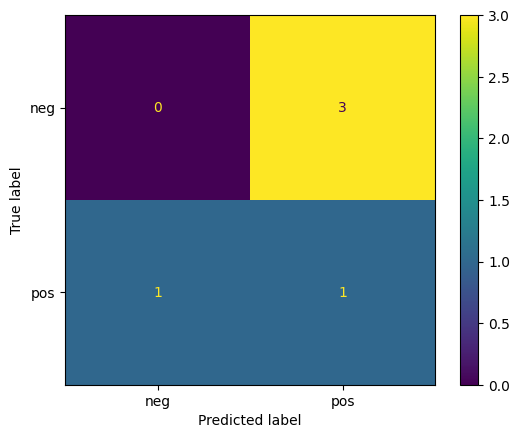

In [21]:
# Confusion matrix sederhana
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, ConfusionMatrixDisplay

X_tr, X_te, y_tr, y_te = train_test_split(X_text, y, test_size=0.34, stratify=y, random_state=RNG)
clf = pipes['NB'].fit(X_tr, y_tr)
y_pred = clf.predict(X_te)
print(classification_report(y_te, y_pred))
ConfusionMatrixDisplay.from_predictions(y_te, y_pred); plt.show()

---
## Tahap 6 — Sequence Labeling: POS & NER

**Tujuan:** mempelahari sequence labeling melalui **POS tagging** dan **Named Entity Recognition**.
Kita gunakan model di library (NLTK + spaCy). Untuk Bahasa Indonesia, gunakan model IndoLEM/IndoBERT-NER . Pada experiment ini, kita demonstrasikan dengan teks bahasa Inggris.

In [22]:
# POS tagging dengan NLTK
import nltk
from nltk import pos_tag
from nltk.tokenize import word_tokenize # Added this import

# Ensure the necessary NLTK resource is downloaded for English POS tagging
try:
    nltk.data.find('taggers/averaged_perceptron_tagger_eng')
except LookupError:
    nltk.download('averaged_perceptron_tagger_eng', quiet=True)

tokens = word_tokenize('The Bank Indonesia raised its interest rate to 5.75 percent on January 23 2026.')
pos = pos_tag(tokens)
pd.DataFrame(pos, columns=['token','pos'])

,token,pos
0,The,DT
1,Bank,NNP
2,Indonesia,NNP
3,raised,VBD
4,its,PRP$
5,interest,NN
6,rate,NN
7,to,TO
8,5.75,CD
9,percent,NN


In [23]:
# NER dengan spaCy
doc = nlp_en('The Bank Indonesia raised its interest rate to 5.75 percent on January 23, 2026.')
for ent in doc.ents:
    print(f'{ent.text:<22} -> {ent.label_}')

Bank Indonesia         -> ORG
5.75 percent           -> PERCENT
January 23, 2026       -> DATE


In [24]:
# Konversi ke skema BIO (input untuk model CRF / BiLSTM-CRF)
def to_bio(doc):
    bio = []
    for tok in doc:
        if tok.ent_iob_ == 'O': bio.append((tok.text, 'O'))
        else: bio.append((tok.text, f'{tok.ent_iob_}-{tok.ent_type_}'))
    return bio

pd.DataFrame(to_bio(doc), columns=['token','tag'])

,token,tag
0,The,O
1,Bank,B-ORG
2,Indonesia,I-ORG
3,raised,O
4,its,O
5,interest,O
6,rate,O
7,to,O
8,5.75,B-PERCENT
9,percent,I-PERCENT


---
## Tahap 7 — Neural NLP: LSTM Classifier dengan PyTorch

**Tujuan:** memahami pipeline tensor → embedding → LSTM → classifier,
dilatih end-to-end dengan back-propagation.

Catatan: untuk dataset kecil ini neural model akan **overfit**.

In [25]:
import torch, torch.nn as nn
from torch.utils.data import Dataset, DataLoader

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print('Device:', device)

# Vocab dari korpus review
all_tokens = [t for txt in reviews_id['text'] for t in preprocess_id(txt)]
PAD, UNK = '<pad>', '<unk>'
vocab = [PAD, UNK] + sorted(set(all_tokens))
stoi  = {w:i for i,w in enumerate(vocab)}
label2id = {'pos':1, 'neg':0}
MAX_LEN = 12

def encode(text):
    ids = [stoi.get(t, 1) for t in preprocess_id(text)][:MAX_LEN]
    ids = ids + [0]*(MAX_LEN - len(ids))
    return ids

class ReviewDS(Dataset):
    def __init__(self, df):
        self.X = torch.tensor([encode(t) for t in df['text']], dtype=torch.long)
        self.y = torch.tensor([label2id[l] for l in df['label']], dtype=torch.long)
    def __len__(self): return len(self.y)
    def __getitem__(self, i): return self.X[i], self.y[i]

ds = ReviewDS(reviews_id)
dl = DataLoader(ds, batch_size=4, shuffle=True)
len(ds), ds[0][0]

Device: cuda


(12, tensor([54,  8,  9, 36, 20, 49, 58,  0,  0,  0,  0,  0]))

In [26]:
class LSTMClassifier(nn.Module):
    def __init__(self, vocab_size, emb_dim=32, hid=32, n_class=2):
        super().__init__()
        self.emb  = nn.Embedding(vocab_size, emb_dim, padding_idx=0)
        self.lstm = nn.LSTM(emb_dim, hid, batch_first=True, bidirectional=True)
        self.fc   = nn.Linear(hid*2, n_class)
    def forward(self, x):
        e = self.emb(x)
        _, (h, _) = self.lstm(e)            # h: (2, B, hid)
        h = torch.cat([h[0], h[1]], dim=-1) # concat dua arah
        return self.fc(h)

torch.manual_seed(RNG)
model = LSTMClassifier(len(vocab)).to(device)
opt   = torch.optim.Adam(model.parameters(), lr=3e-3)
lossf = nn.CrossEntropyLoss()

for ep in range(40):
    total = 0
    for X, y in dl:
        X, y = X.to(device), y.to(device)
        logits = model(X)
        loss = lossf(logits, y)
        opt.zero_grad(); loss.backward(); opt.step()
        total += loss.item()
    if (ep+1) % 10 == 0:
        print(f'Epoch {ep+1:>2}  loss={total/len(dl):.4f}')

Epoch 10  loss=0.0908
Epoch 20  loss=0.0011
Epoch 30  loss=0.0005
Epoch 40  loss=0.0004


In [27]:
# Inferensi
model.eval()
tests = ['Pelayanan ramah dan cepat', 'Barang sangat mengecewakan dan rusak']
with torch.no_grad():
    for t in tests:
        x = torch.tensor([encode(t)]).to(device)
        p = model(x).softmax(-1)[0].cpu().numpy()
        print(f'{t!r:<45}  P(pos)={p[1]:.2f}')

'Pelayanan ramah dan cepat'                    P(pos)=1.00
'Barang sangat mengecewakan dan rusak'         P(pos)=0.00


---
## Tahap 8 — Pretrained Transformers (Hugging Face)

**Tujuan:** memanfaatkan model pretrained — tanpa fine-tuning — lalu sekilas memperlihatkan
alur **fine-tuning** untuk klasifikasi.


In [28]:
from transformers import pipeline

# Sentiment dalam English (pretrained, nol fine-tuning)
senti = pipeline('sentiment-analysis')
print(senti(['I love this product', 'This is terrible']))

No model was supplied, defaulted to distilbert/distilbert-base-uncased-finetuned-sst-2-english and revision 714eb0f (https://huggingface.co/distilbert/distilbert-base-uncased-finetuned-sst-2-english).
Using a pipeline without specifying a model name and revision in production is not recommended.


config.json:   0%|          | 0.00/629 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

Device set to use cuda:0


[{'label': 'POSITIVE', 'score': 0.9998788833618164}, {'label': 'NEGATIVE', 'score': 0.9996459484100342}]


In [29]:
# NER pretrained
ner = pipeline('ner', aggregation_strategy='simple')
for e in ner('Bank Indonesia raised rates on January 23 2026.'):
    print(f'{e["word"]:<22} {e["entity_group"]:<6} score={e["score"]:.2f}')

No model was supplied, defaulted to dbmdz/bert-large-cased-finetuned-conll03-english and revision 4c53496 (https://huggingface.co/dbmdz/bert-large-cased-finetuned-conll03-english).
Using a pipeline without specifying a model name and revision in production is not recommended.


config.json:   0%|          | 0.00/998 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.33G [00:00<?, ?B/s]

Some weights of the model checkpoint at dbmdz/bert-large-cased-finetuned-conll03-english were not used when initializing BertForTokenClassification: ['bert.pooler.dense.bias', 'bert.pooler.dense.weight']
- This IS expected if you are initializing BertForTokenClassification from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing BertForTokenClassification from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).


tokenizer_config.json:   0%|          | 0.00/60.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

Device set to use cuda:0


Bank Indonesia         ORG    score=1.00


### 8.x Summarization

**Note:** jika Anda menggunakan Colab dan sudah menjalankan Workshop 1–7, kemungkinan besar kernel Colab
sudah mendekati batas RAM. Loading model summarization HF tambahan sering memicu
*'Session crashed for unknown reason'* — itu OOM, bukan bug.

**Strategi:**
1. Jalankan dulu **extractive summarization** (cell di bawah) — tidak butuh HuggingFace, cepat & ringan.
2. Untuk versi abstractive (HF), bersihkan memori dulu, atau jalankan di runtime baru.

In [30]:
# === Extractive summarization manual (tanpa HuggingFace) ===
# Pendekatan: skor tiap kalimat dengan TF-IDF rata-rata, pilih top-k.
from sklearn.feature_extraction.text import TfidfVectorizer
import numpy as np, re

doc = ('Bank Indonesia announced a 25 basis-point hike to its benchmark interest rate, '
       'pushing it to 5.75 percent. The move follows persistent inflation in food prices '
       'and aims to support the rupiah, which has weakened against the US dollar. '
       'Analysts expect the central bank to maintain a hawkish stance through Q2.')

def extractive_summary(text: str, k: int = 2) -> str:
    sents = re.split(r'(?<=[.!?])\s+', text.strip())
    if len(sents) <= k: return text
    tfidf = TfidfVectorizer().fit_transform(sents)
    scores = np.asarray(tfidf.mean(axis=1)).ravel()
    top = sorted(scores.argsort()[-k:])    # urut sesuai posisi asli
    return ' '.join(sents[i] for i in top)

print(extractive_summary(doc, k=2))

Bank Indonesia announced a 25 basis-point hike to its benchmark interest rate, pushing it to 5.75 percent. The move follows persistent inflation in food prices and aims to support the rupiah, which has weakened against the US dollar.


#### 8.x.opt — Abstractive summarization dengan HuggingFace (opsional)

Jalankan **hanya jika** Anda punya RAM cukup. Tips agar tidak crash:
- Jalankan cell pembersih memori di bawah dulu.
- Atau lebih aman: **Runtime → Disconnect and delete runtime**, mulai notebook baru, jalankan **hanya** cell ini.

In [31]:
# Cell pembersih — jalankan sebelum loading HF model
import gc
for name in ['model','w2v','tfv','X_bow','X','vecs','encoder','doc_emb','ds','dl','lr','clf']:
    if name in globals(): del globals()[name]
gc.collect()
try:
    import torch
    if torch.cuda.is_available(): torch.cuda.empty_cache()
except Exception: pass
print('RAM dibersihkan. Lanjut load HF model.')

RAM dibersihkan. Lanjut load HF model.


In [33]:
# Abstractive summarization — versi memory-efficient
# Catatan: butuh `sentencepiece` dan ~700 MB RAM.
# !pip install -q sentencepiece
from transformers import pipeline
import torch

summ = pipeline(
    'summarization',
    model='Falconsai/text_summarization',  # T5-base distil, ~250MB, andal di Colab
    dtype=torch.float32,
)
doc = ('Bank Indonesia announced a 25 basis-point hike to its benchmark interest rate, '
       'pushing it to 5.75 percent. The move follows persistent inflation in food prices '
       'and aims to support the rupiah, which has weakened against the US dollar.')
print(summ(doc, max_length=40, min_length=15, do_sample=False)[0]['summary_text'])

Device set to use cuda:0
Both `max_new_tokens` (=256) and `max_length`(=40) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Bank Indonesia announced a 25 basis-point hike to its benchmark interest rate . The move follows persistent inflation in food prices and aims to support the rupiah .


### 8.1 Sketsa fine-tuning IndoBERT untuk klasifikasi sentimen



In [34]:
FINE_TUNE_TEMPLATE = '''
from datasets import load_dataset
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments

ds   = load_dataset('indonlu', 'smsa')
ckpt = 'indolem/indobert-base-uncased'
tok  = AutoTokenizer.from_pretrained(ckpt)
model = AutoModelForSequenceClassification.from_pretrained(ckpt, num_labels=3)

def encode(b): return tok(b['text'], truncation=True, padding='max_length', max_length=128)
ds = ds.map(encode, batched=True)

args = TrainingArguments(output_dir='out', num_train_epochs=3,
    per_device_train_batch_size=16, evaluation_strategy='epoch',
    learning_rate=2e-5, fp16=True, logging_steps=50)
Trainer(model=model, args=args,
        train_dataset=ds["train"], eval_dataset=ds["validation"]).train()
'''
print(FINE_TUNE_TEMPLATE)


from datasets import load_dataset
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments

ds   = load_dataset('indonlu', 'smsa')
ckpt = 'indolem/indobert-base-uncased'
tok  = AutoTokenizer.from_pretrained(ckpt)
model = AutoModelForSequenceClassification.from_pretrained(ckpt, num_labels=3)

def encode(b): return tok(b['text'], truncation=True, padding='max_length', max_length=128)
ds = ds.map(encode, batched=True)

args = TrainingArguments(output_dir='out', num_train_epochs=3,
    per_device_train_batch_size=16, evaluation_strategy='epoch',
    learning_rate=2e-5, fp16=True, logging_steps=50)
Trainer(model=model, args=args,
        train_dataset=ds["train"], eval_dataset=ds["validation"]).train()



---
## Tahap 9 — Era LLM: Embedding & Mini-RAG

**Tujuan:** memahami fondasi RAG (Retrieval-Augmented Generation):
encode dokumen → cari top-k berdasarkan cosine similarity → jadikan konteks.

Kita gunakan `sentence-transformers` (model multibahasa) untuk membuat embedding.

In [35]:
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity

encoder = SentenceTransformer('paraphrase-multilingual-MiniLM-L12-v2')
doc_emb = encoder.encode(news_corpus, normalize_embeddings=True)
doc_emb.shape

modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/645 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/526 [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.08M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

(10, 384)

In [36]:
def search(query, k=3):
    q = encoder.encode([query], normalize_embeddings=True)
    sims = cosine_similarity(q, doc_emb)[0]
    top = sims.argsort()[::-1][:k]
    return [(news_corpus[i], float(sims[i])) for i in top]

for txt, sc in search('kenaikan suku bunga'):
    print(f'{sc:.3f}  {txt}')

0.324  Bank Indonesia menaikkan suku bunga acuan menjadi 5,75 persen pada Januari.
0.220  Kementerian Keuangan menetapkan target pertumbuhan ekonomi sebesar 5,2 persen.
0.148  Pemerintah merilis paket stimulus untuk usaha kecil dan menengah.


### 9.1 Sketsa RAG end-to-end

Pseudocode di bawah memperlihatkan *pattern* RAG: retrieval + prompt + generation.
Pada implementasi riil, ganti `call_llm` dengan API LLM Anda.

In [37]:
PROMPT_TEMPLATE = '''Anda adalah asisten yang menjawab hanya berdasarkan KONTEKS.
KONTEKS:
{context}

PERTANYAAN: {question}
JAWABAN (singkat, dengan sumber per kalimat):'''

def rag(question, k=3):
    hits = search(question, k=k)
    context = '\n'.join(f'[{i+1}] {t}' for i,(t,_) in enumerate(hits))
    prompt = PROMPT_TEMPLATE.format(context=context, question=question)
    return prompt, hits

prompt, hits = rag('Berapa suku bunga acuan Bank Indonesia saat ini?')
print(prompt)
print('\nRetrieved:', [h[0] for h in hits])

Anda adalah asisten yang menjawab hanya berdasarkan KONTEKS.
KONTEKS:
[1] Bank Indonesia menaikkan suku bunga acuan menjadi 5,75 persen pada Januari.
[2] Cadangan devisa Indonesia naik menjadi 144 miliar dolar pada Februari.
[3] Bursa saham Indonesia menguat ditopang aksi beli investor asing.

PERTANYAAN: Berapa suku bunga acuan Bank Indonesia saat ini?
JAWABAN (singkat, dengan sumber per kalimat):

Retrieved: ['Bank Indonesia menaikkan suku bunga acuan menjadi 5,75 persen pada Januari.', 'Cadangan devisa Indonesia naik menjadi 144 miliar dolar pada Februari.', 'Bursa saham Indonesia menguat ditopang aksi beli investor asing.']


---
## Latihan Eksplorasi Mandiri (PR)

1. **Preprocessing custom** — bangun pipeline preprocessing untuk dataset Twitter Bahasa Indonesia (gunakan dataset publik).
Bandingkan jumlah token sebelum/sesudah stopword removal.
2. **TF-IDF + clustering** — gunakan `KMeans` pada matriks TF-IDF dari `news_corpus` (perbesar) untuk membentuk topik.
Visualisasikan dengan PCA/UMAP.
3. **Bigram LM** — latih bigram model, hitung perplexity
pada test split, dan generate 5 kalimat sintetis.
4. **Compare classifiers** — pada dataset SmSA IndoNLU, bandingkan Naive Bayes, Logistic Regression, LSTM, dan IndoBERT
(F1-macro, train time, inference latency).

Bonus. **Mini-RAG** — bangun retriever pada koleksi 200 dokumen Wikipedia berbahasa Indonesia, evaluasi recall@5
untuk 20 pertanyaan yang Anda buat sendiri.

---
**Submit:** notebook + laporan singkat (≤ 4 halaman) berisi metodologi, hasil, dan analisis kesalahan.
Gunakan **error analysis** kualitatif sebagai bobot utama.

---
### Referensi inti

- Eisenstein, J. (2018). *Natural Language Processing*. MIT Press.
- Jurafsky, D. & Martin, J. H. (2024). *Speech and Language Processing* (3rd ed., draft).
- Lee, R. S. T. (2024). *Natural Language Processing: A Textbook with Python Implementation*. Springer.
- Mikolov et al. (2013); Vaswani et al. (2017); Devlin et al. (2018); Lewis et al. (2020 — RAG).

**Library docs**: `nltk`, `spacy`, `gensim`, `scikit-learn`, `pytorch`, `transformers`, `sentence-transformers`, `Sastrawi`.